# Model SARIMA - Anàlisi de sèries temporals (Sèrie 4)

Aquest notebook analitza la sèrie temporal de casos de faringoamigdalitis en població de 0 a 14 anys a la regió BCN Nord, utilitzant la metodologia Box-Jenkins. L’anàlisi inclou l’ajust del model, la validació i la predicció, a partir de dades setmanals del període 2012–2024.

## Metodologia

1. Anàlisi exploratòria
2. Anàlisi d’estacionarietat
3. Identificació del model
4. Estimació del model
5. Validació
6. Predicció

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import statsmodels.api as sm
import skforecast
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme, plot_prediction_intervals
from skforecast.stats import Sarimax, Arima
from skforecast.recursive import ForecasterStats
from skforecast.utils import expand_index
from skforecast.model_selection import TimeSeriesFold, backtesting_stats, grid_search_stats

warnings.filterwarnings('once')
warnings.filterwarnings('ignore', category=DeprecationWarning)

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

## Filtratge de dades

Es selecciona el subconjunt corresponent a:

- Diagnòstic: Faringoamigdalitis  
- Regió: Barcelona Metropolitana Nord  
- Grup d’edat: 0–14 anys

In [2]:
df_serie = df[
    (df["diagnostic"] == "Faringoamigdalitis") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "0-14")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"].sum().sort_index()
)
serie = serie.asfreq("W-MON")

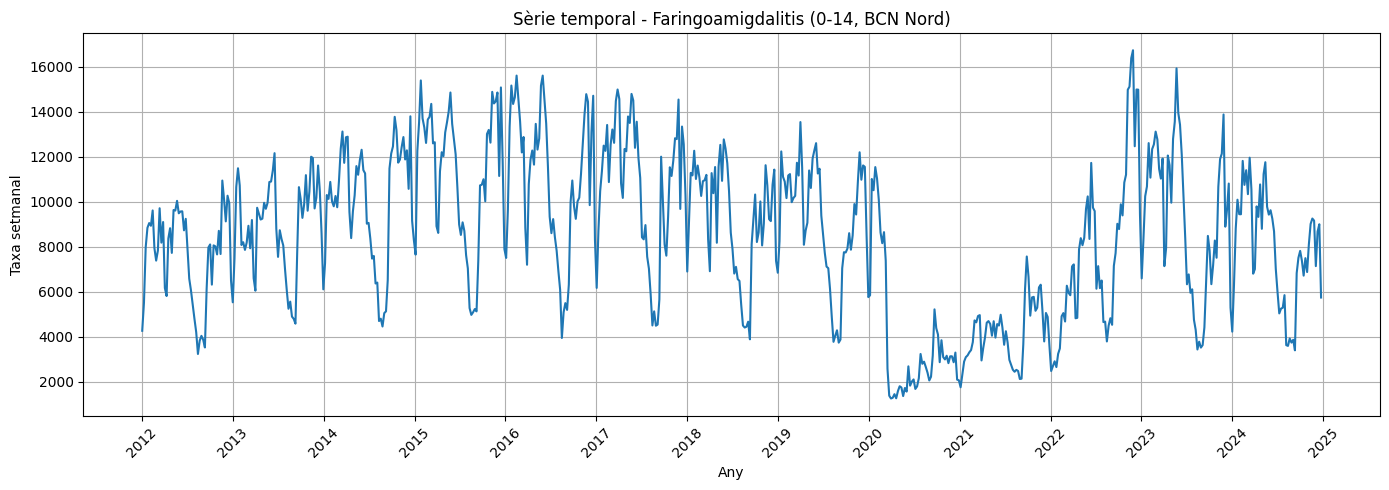

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Sèrie temporal - Faringoamigdalitis (0-14, BCN Nord)")
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Divisió Train-Test

El conjunt de dades es divideix en:

- Conjunt d’entrenament: utilitzat per a l’estimació del model (2012–2019)  
- Conjunt test: utilitzat per a la validació i l’avaluació del rendiment predictiu (2020–2024)

In [4]:
serie_4 = serie.copy()

train = serie_4[serie_4.index < "2020-01-01"]
test  = serie_4[serie_4.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


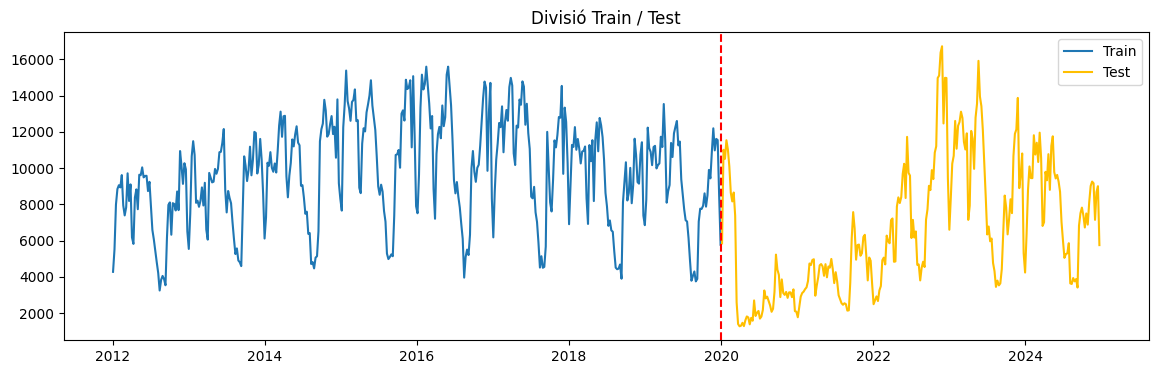

In [5]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

plt.figure(figsize=(14,4))

plt.plot(train, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train / Test")
plt.show()

## Anàlisi exploratòria

La sèrie temporal mostra:

- Possible tendència
- Estacionalitat
- Variabilitat al llarg del temps

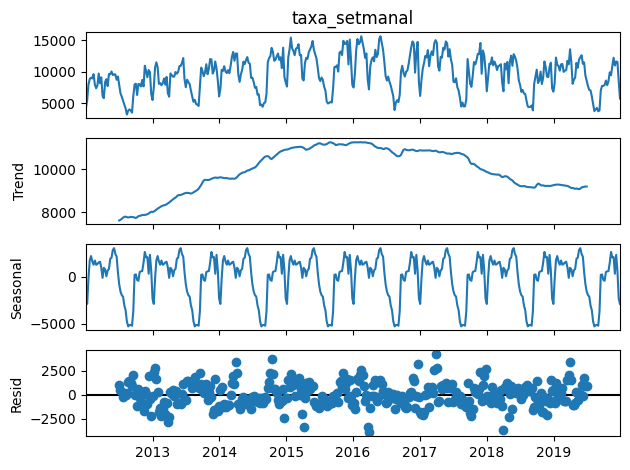

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

S’ha provat una transformació logarítmica/Box-Cox per estabilitzar la variància. Tanmateix, no s’ha observat cap millora significativa en la variància mòbil, la selecció del model mitjançant l’ACF/PACF ni el rendiment predictiu.

Per tant, s’ha mantingut l’escala original de la sèrie.

## ACF original

Després de la descomposició, s’examina l’ACF de la sèrie original per avaluar la possible presència d’estacionalitat.

Els pics significatius en retards estacionals, especialment al voltant de m = 52, suggereixen un patró estacional anual clar. Això proporciona una primera indicació que podria ser necessària una diferenciació estacional.

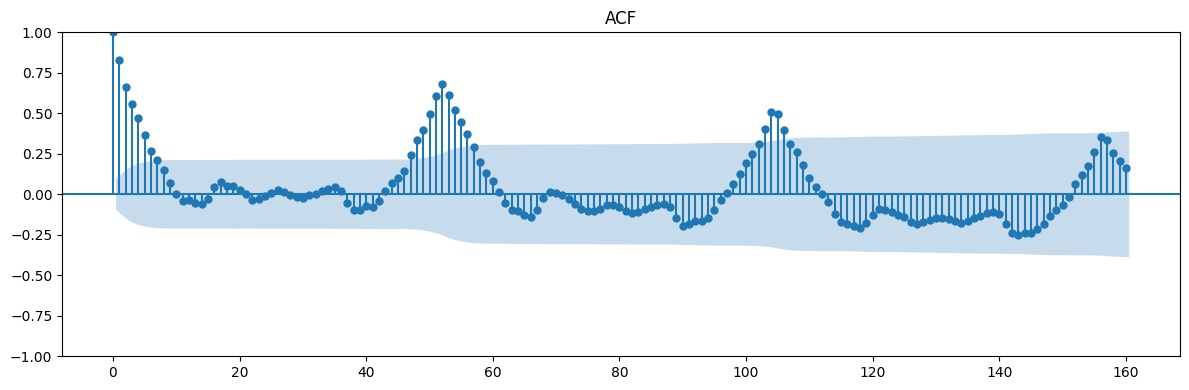

In [7]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train, lags=160, ax=ax)

ax.set_title("ACF")
plt.tight_layout()
plt.show()

## Anàlisi d’estacionarietat

S’apliquen les proves estadístiques següents:
- Test Augmented Dickey-Fuller (ADF)
- Test KPSS

## Interpretació
- ADF: H0 = no estacionària
- KPSS: H0 = estacionària

Resultats sobre la sèrie transformada logarítmicament:

- Test ADF: es rebutja la hipòtesi nul·la de no estacionarietat
- Test KPSS: no es rebutja la hipòtesi nul·la d’estacionarietat

Tots dos tests suggereixen estacionarietat sota les seves respectives hipòtesis, tot i que diagnòstics addicionals indiquen que, en la pràctica, la sèrie no és plenament estacionària.

In [8]:
dftest = adfuller(train, autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("P-Valor : ", dftest[1])

stat, p_value, lags, crit = kpss(train, regression='c', nlags='auto')

print("\n2. KPSS :", stat)
print("P-valor:", p_value)

1. ADF :  -3.769741283038257
P-Valor :  0.003232524724397349

2. KPSS : 0.36649386555803215
P-valor: 0.09159747174222752


## Anàlisi descriptiva

Per complementar els tests estadístics, s’analitzen els següents elements:

- Mitjana mòbil
- Variància mòbil

Resultats:

- La mitjana no és constant al llarg del temps
- La variància mostra fluctuacions apreciables

Això suggereix que la sèrie no és plenament estacionària en la pràctica.

In [9]:
print("Mitjana global (train):", train.mean())
print("Variància global (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\nMitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

Mitjana global (train): 9717.021550219348
Variància global (train): 8116486.9643412

Mitjana per any:
date
2012-12-31     7580.964797
2013-12-31     8908.871476
2014-12-31    10051.712922
2015-12-31    11190.123653
2016-12-31    10972.816840
2017-12-31    10719.413890
2018-12-31     9176.220134
2019-12-31     9187.526731
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    4.165859e+06
2013-12-31    4.024630e+06
2014-12-31    6.609617e+06
2015-12-31    9.100379e+06
2016-12-31    9.947513e+06
2017-12-31    8.912911e+06
2018-12-31    5.811719e+06
2019-12-31    6.639339e+06
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


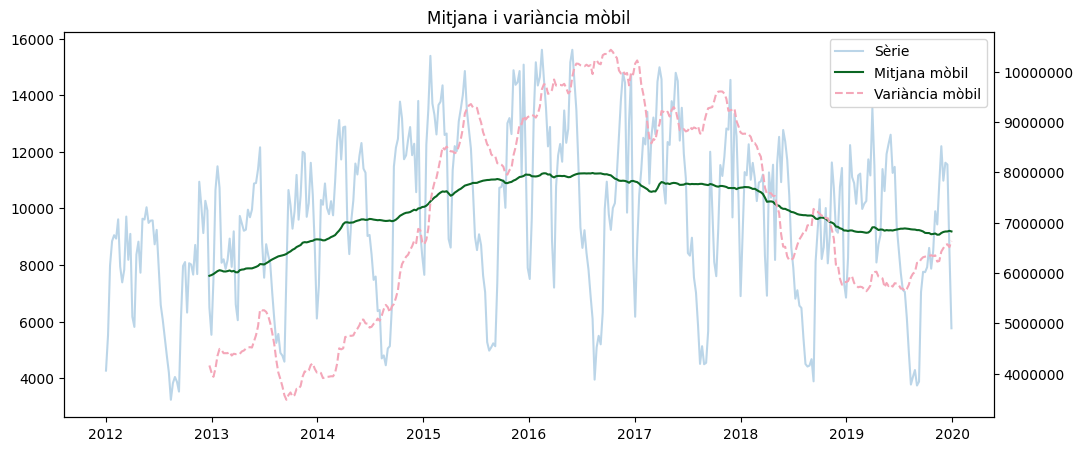

In [10]:
rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_mean, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Mitjana i variància mòbil")
plt.show()

## Comprovació de la diferenciació estacional

Per avaluar més a fons si la diferenciació estacional és adequada, es compara la sèrie després d’aplicar una diferenciació estacional amb la sèrie original, i s’examina novament l’ACF.

Després d’aplicar la diferenciació estacional, el patró anual repetitiu queda substancialment atenuat, i els pics estacionals de l’ACF esdevenen notablement més febles. Això suporta l’elecció d’una diferenciació estacional d’ordre 1 (D = 1).

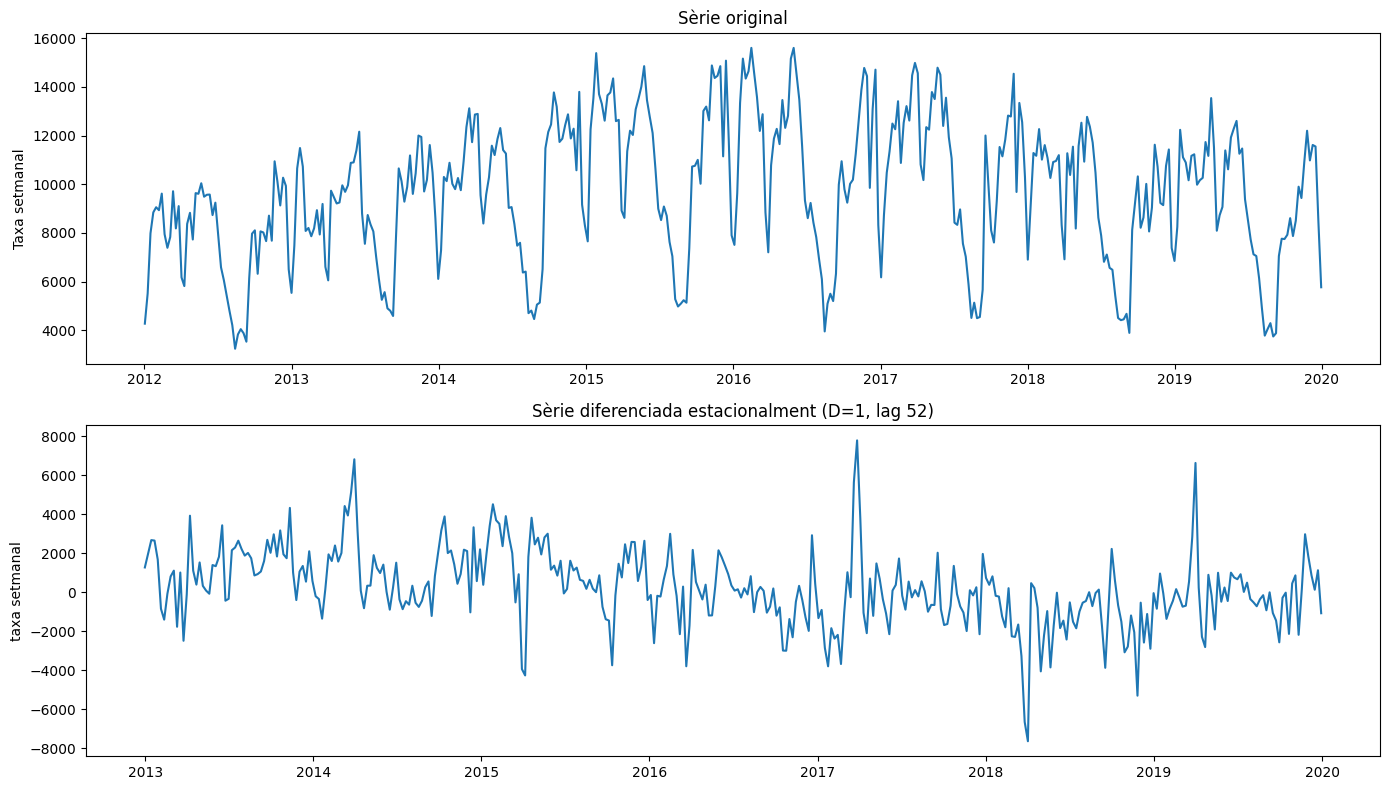

In [11]:
serie_D1 = train.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train)
axes[0].set_title("Sèrie original")
axes[0].set_ylabel("Taxa setmanal")

axes[1].plot(serie_D1)
axes[1].set_title("Sèrie diferenciada estacionalment (D=1, lag 52)")
axes[1].set_ylabel("taxa setmanal")

plt.tight_layout()
plt.show()

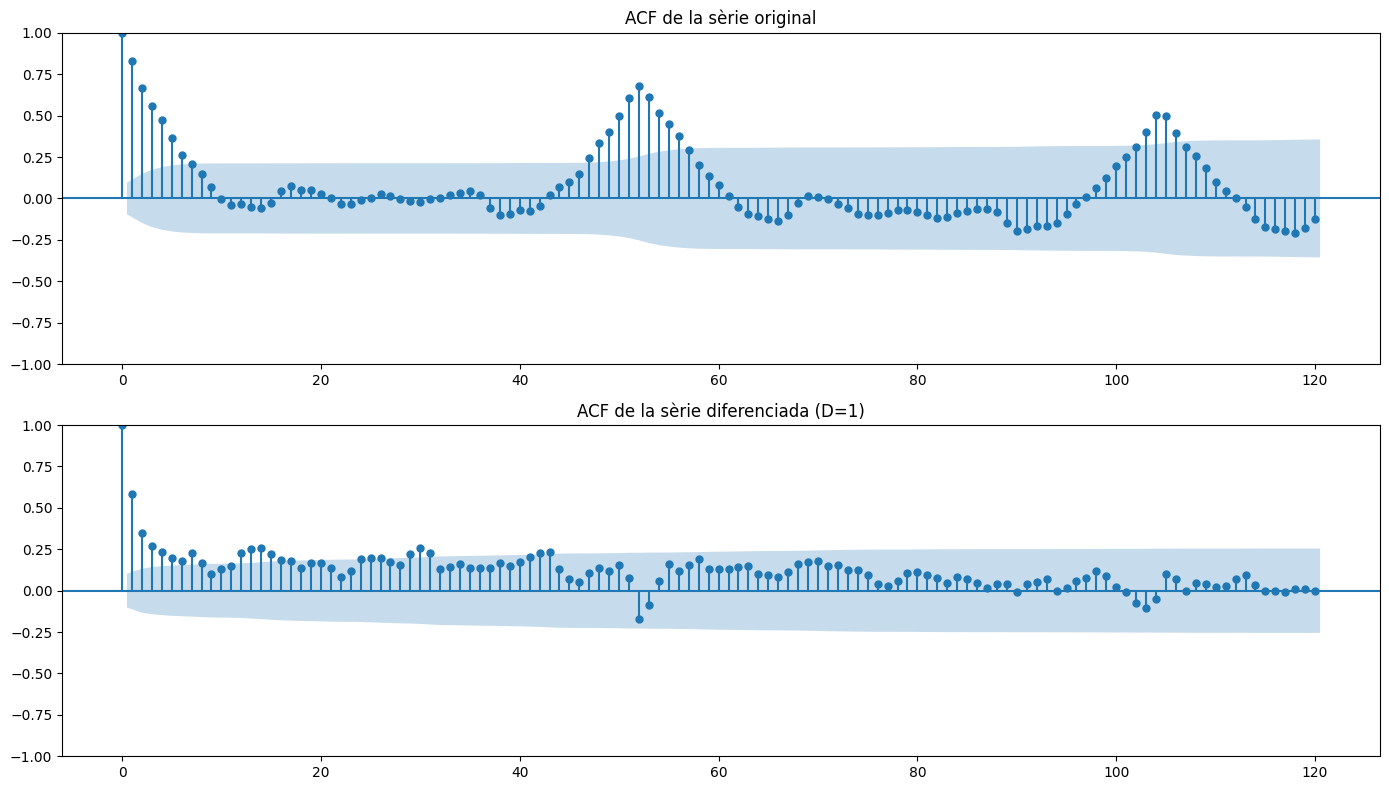

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF de la sèrie original")

plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF de la sèrie diferenciada (D=1)")

plt.tight_layout()
plt.show()

## Selecció de la diferenciació

Tot i que els tests ADF i KPSS suggereixen estacionarietat, l’anàlisi addicional indica que la mitjana no és del tot estable al llarg del temps. En particular, la mitjana mòbil encara mostra certa variació durant el període d’entrenament i, després d’aplicar només la diferenciació estacional, l’ACF continua presentant una persistència a curt termini apreciable.

Davant l’evidència contradictòria entre els tests formals i els diagnòstics descriptius, també s’adopta una diferenciació no estacional de primer ordre. Després d’aplicar tant la diferenciació regular com l’estacional, l’estructura de dependència esdevé substancialment més estable, i l’ACF/PACF no mostren signes clars de sobrediferenciació severa.

Aquesta transformació estabilitza l’estructura de la mitjana i fa que la sèrie sigui més adequada per a la modelització SARIMA.

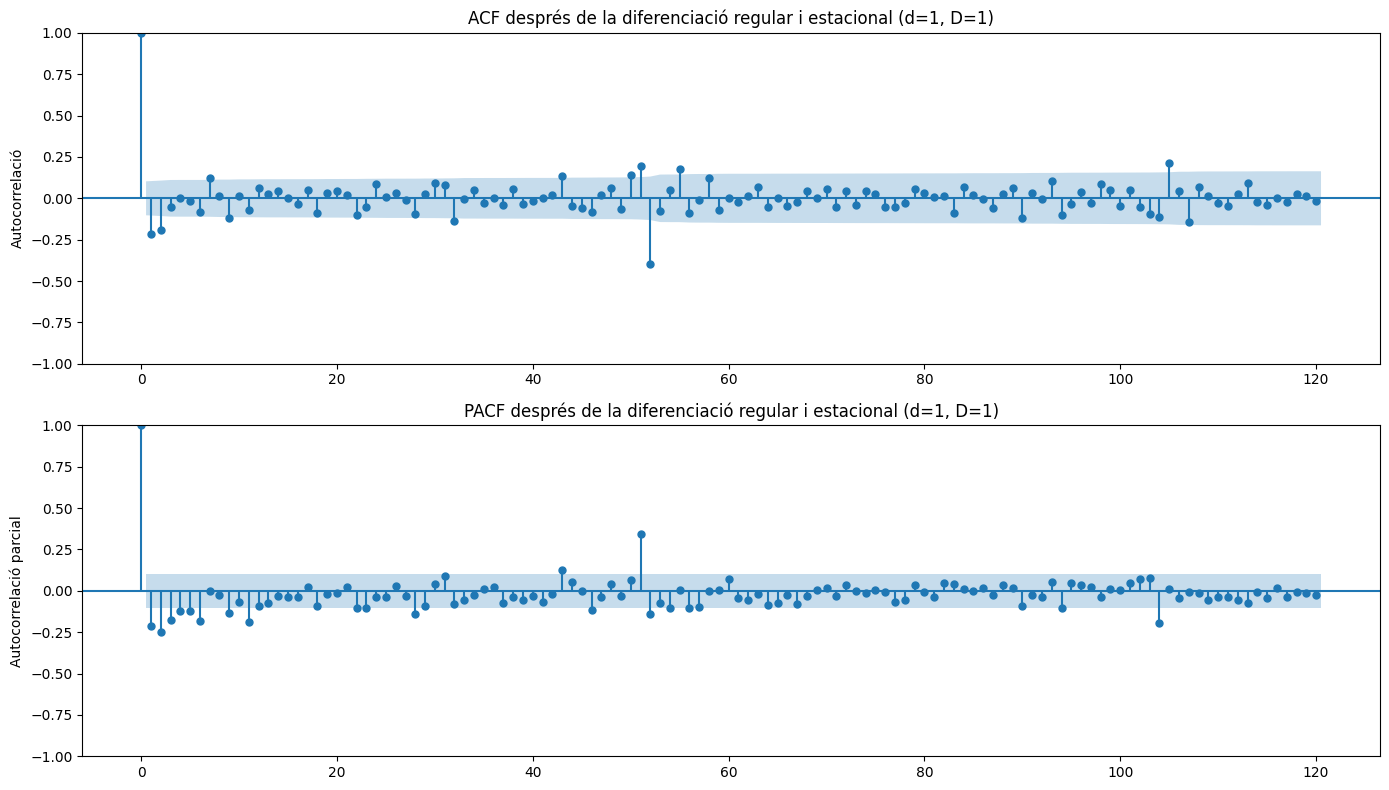

In [13]:
serie_d1D1 = serie_D1.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_d1D1, lags=120, ax=axes[0])
axes[0].set_title("ACF després de la diferenciació regular i estacional (d=1, D=1)")
axes[0].set_ylabel("Autocorrelació")

plot_pacf(serie_d1D1, lags=120, ax=axes[1])
axes[1].set_title("PACF després de la diferenciació regular i estacional (d=1, D=1)")
axes[1].set_ylabel("Autocorrelació parcial")

plt.tight_layout()
plt.show()

## Selecció del model

Es proven diversos models SARIMA a partir de la informació proporcionada per l’ACF i la PACF, i es comparen mitjançant el criteri AIC.

Cada model s’ajusta utilitzant les dades d’entrenament.

In [14]:
models = [
    ((1,1,1), (0,1,1,52)),
    ((2,1,1), (0,1,1,52)),
    ((1,1,2), (0,1,1,52)),
    ((2,1,2), (0,1,1,52)),
    ((1,1,2), (0,1,0,52)),
    ((1,1,2), (1,1,1,52)),
    ((1,1,1), (1,1,1,52)),
    ((2,1,2), (1,1,1,52)),
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA {order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA {order}{seasonal_order}")

print("\n Millor model:")
print(best_model)
print("AIC:", best_aic)


Model SARIMA (1, 1, 1)(0, 1, 1, 52)
AIC: 5354.6242473721895
----------------------------------------
Model SARIMA (2, 1, 1)(0, 1, 1, 52)
AIC: 5356.125922960049
----------------------------------------
Model SARIMA (1, 1, 2)(0, 1, 1, 52)
AIC: 5338.75966817522
----------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model SARIMA (2, 1, 2)(0, 1, 1, 52)
AIC: 5340.21408633495
----------------------------------------
Model SARIMA (1, 1, 2)(0, 1, 0, 52)
AIC: 6355.210915877795
----------------------------------------
Model SARIMA (1, 1, 2)(1, 1, 1, 52)
AIC: 5339.476920526368
----------------------------------------
Model SARIMA (1, 1, 1)(1, 1, 1, 52)
AIC: 5395.866516588091
----------------------------------------
Model SARIMA (2, 1, 2)(1, 1, 1, 52)
AIC: 5366.182724510908
----------------------------------------

 Millor model:
((1, 1, 2), (0, 1, 1, 52))
AIC: 5338.75966817522


In [15]:
model1 = SARIMAX(train,
                order=(1,1,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 52)   Log Likelihood               -2664.380
Date:                              Sat, 25 Apr 2026   AIC                           5338.760
Time:                                      18:32:46   BIC                           5357.443
Sample:                                  01-02-2012   HQIC                          5346.228
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4630      0.097      4.751      0.000       0.272       0.654
ma.L1         -0.88

In [16]:
model2 = SARIMAX(train,
                order=(1,1,2),
                seasonal_order=(1,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2 = model2.fit()
print(result2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 52)   Log Likelihood               -2663.738
Date:                              Sat, 25 Apr 2026   AIC                           5339.477
Time:                                      18:32:53   BIC                           5361.896
Sample:                                  01-02-2012   HQIC                          5348.439
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4483      0.098      4.563      0.000       0.256       0.641
ma.L1         -0.87

In [17]:
model3 = SARIMAX(train,
                order=(2,1,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result3 = model3.fit()
print(result3.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 52)   Log Likelihood               -2664.107
Date:                              Sat, 25 Apr 2026   AIC                           5340.214
Time:                                      18:33:03   BIC                           5362.634
Sample:                                  01-02-2012   HQIC                          5349.176
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9612      1.509      0.637      0.524      -1.996       3.919
ar.L2         -0.24

In [18]:
model4 = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result4 = model4.fit()
print(result4.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 52)   Log Likelihood               -2673.312
Date:                            Sat, 25 Apr 2026   AIC                           5354.624
Time:                                    18:33:11   BIC                           5369.583
Sample:                                01-02-2012   HQIC                          5360.604
                                     - 12-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5098      0.049     10.326      0.000       0.413       0.607
ma.L1         -0.9461      0.021   

## Selecció del model per a la validació dels residus

Entre els models candidats inicials, es va dur a terme una avaluació detallada basada en els criteris d’informació, la significació dels paràmetres i l’adequació general del model.

A partir d’aquesta primera comparació, es van retenir tres models com els candidats més sòlids per a una anàlisi posterior. Un model addicional es va descartar en aquesta etapa perquè incloïa paràmetres no significatius i presentava problemes de convergència, cosa que feia que les seves estimacions fossin menys fiables.

Per fer aquesta anàlisi més rigorosa, els diagnòstics es calculen excloent el període inicial de burn-in, ja que els primers residus poden estar afectats per la inicialització del filtre en l’estimació SARIMA.

Burn-in utilitzat: 108


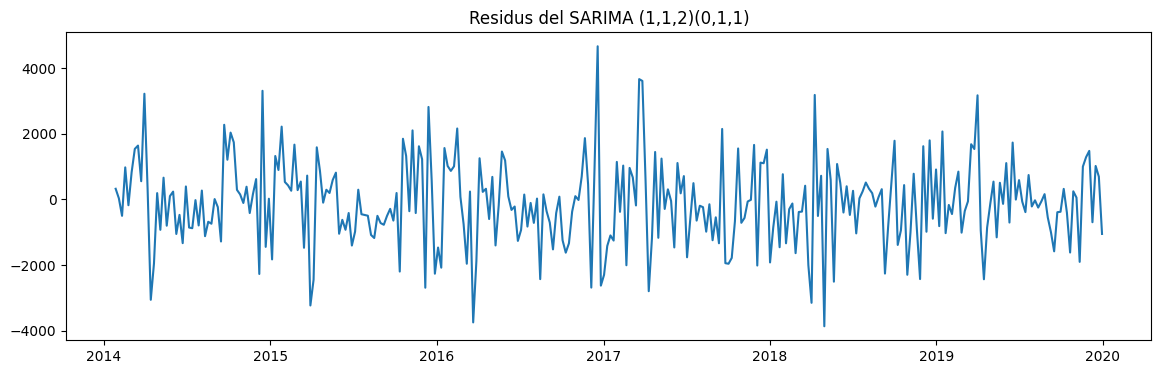

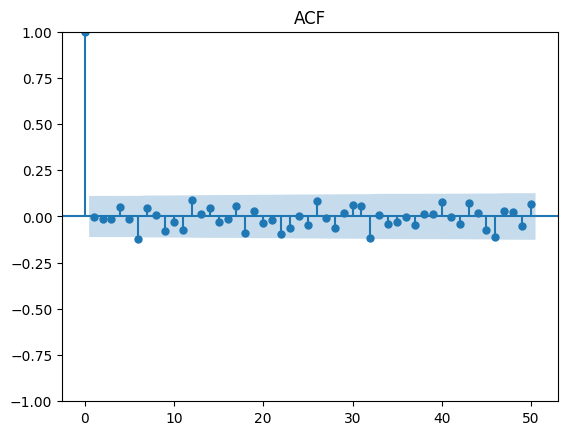


 Ljung Box
      lb_stat  lb_pvalue
10   8.654779   0.565149
20  18.522555   0.553026
30  28.810069   0.527590

Mitjana dels residus: -122.65672480396508
Desviació estàndard dels residus: 1303.107956233982
Mitjana relativa (|mitjana| / desviació estàndard): 0.09412629568961148


In [19]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual1 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual1)
plt.title("Residus del SARIMA (1,1,2)(0,1,1)")
plt.show()

plot_acf(residual1, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual1, lags=[10, 20, 30], return_df=True))

mean_resid = residual1.mean()
std_resid = residual1.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

Burn-in utilitzat: 108


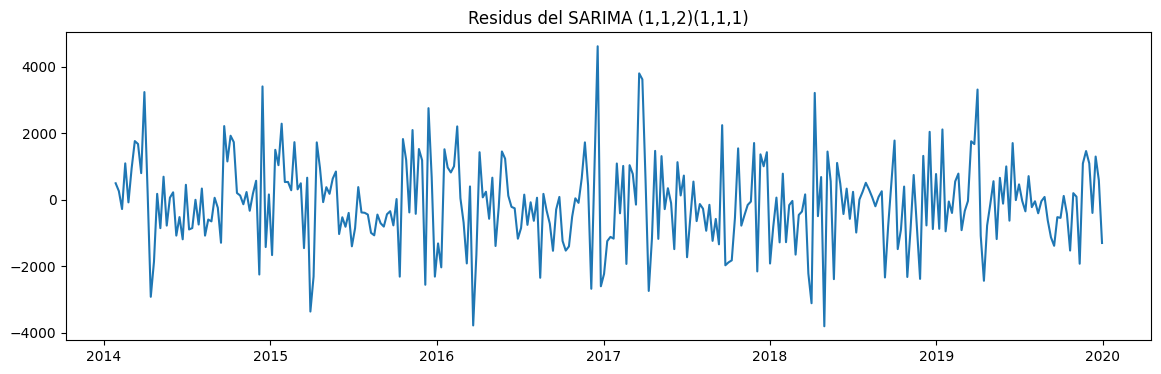

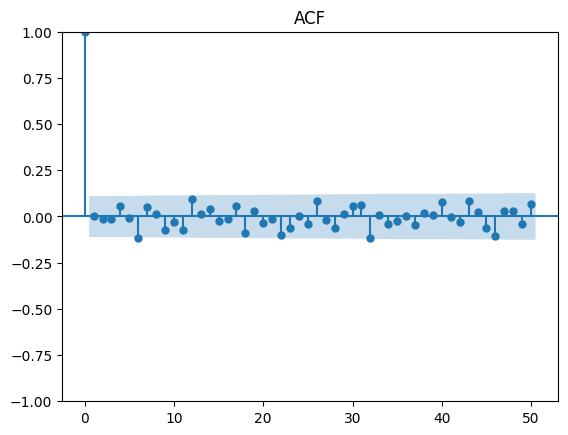


Ljung-Box
      lb_stat  lb_pvalue
10   8.319906   0.597620
20  18.217947   0.573054
30  28.593515   0.539016

Mitjana dels residus: -109.49145895153957
Desviació estàndard dels residus: 1301.5076584900062
Mitjana relativa (|mitjana| / desviació estàndard): 0.08412663439765715


In [20]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual2)
plt.title("Residus del SARIMA (1,1,2)(1,1,1)")
plt.show()

plot_acf(residual2, lags=50)
plt.title("ACF")
plt.show()

print("\nLjung-Box")
print(acorr_ljungbox(residual2, lags=[10, 20, 30], return_df=True))

mean_resid = residual2.mean()
std_resid = residual2.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

Burn-in utilitzat: 107


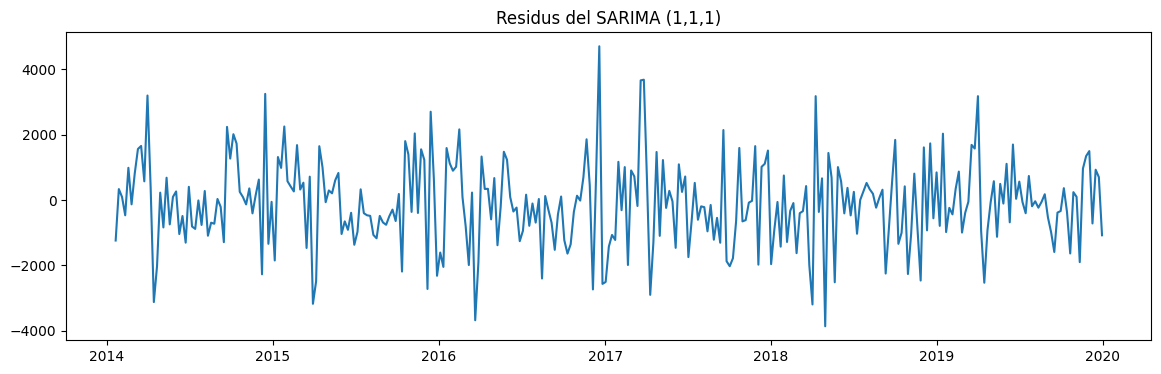

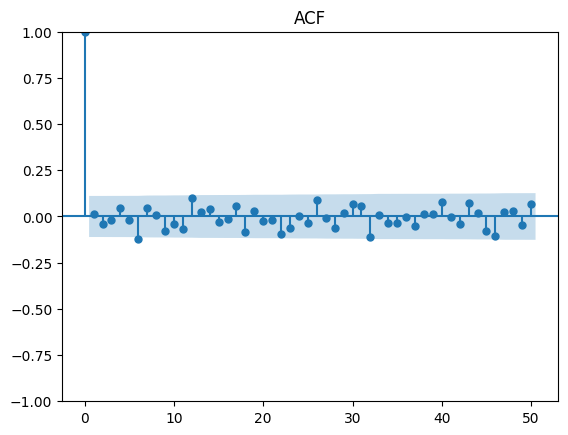


Ljung-Box
      lb_stat  lb_pvalue
10   9.474886   0.487704
20  19.336789   0.500041
30  29.860314   0.472824

Mitjana dels residus: -123.14899502092321
Desviació estàndard dels residus: 1304.30069078186
Mitjana relativa (|mitjana| / desviació estàndard): 0.09441764149270045


In [21]:
residuals= result4.resid.dropna()
burn = max(result4.loglikelihood_burn, result4.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual4 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual4)
plt.title("Residus del SARIMA (1,1,1)")
plt.show()

plot_acf(residual4, lags=50)
plt.title("ACF")
plt.show()

print("\nLjung-Box")
print(acorr_ljungbox(residual4, lags=[10, 20, 30], return_df=True))

mean_resid = residual4.mean()
std_resid = residual4.std()

ratio = abs(mean_resid) / std_resid

print("\nMitjana dels residus:", mean_resid)
print("Desviació estàndard dels residus:", std_resid)
print("Mitjana relativa (|mitjana| / desviació estàndard):", ratio)

## Resultats de la validació dels residus

En tots els casos, l’autocorrelació residual és baixa, la mitjana dels residus es manté propera a zero i el test de Ljung–Box no proporciona evidència en contra de la hipòtesi de soroll blanc als retards considerats. Tot i que la normalitat no és perfecta, això no és inusual en aplicacions pràctiques de sèries temporals i no invalida l’adequació general dels models.

Com que els tres candidats presenten diagnòstics residuals força similars, la comparació final es complementa amb una petita avaluació predictiva fora de mostra basada en mesures de precisió com el MAE i l’RMSE.

In [22]:
# Model 1
pred1 = result1.get_forecast(steps=len(test))
pred1_mean = pred1.predicted_mean

mae1 = mean_absolute_error(test, pred1_mean)
rmse1= root_mean_squared_error(test, pred1_mean)

# Model 2
pred2 = result2.get_forecast(steps=len(test))
pred2_mean = pred2.predicted_mean

mae2 = mean_absolute_error(test, pred2_mean)
rmse2= root_mean_squared_error(test, pred2_mean)

# Model 4
pred4 = result4.get_forecast(steps=len(test))
pred4_mean = pred4.predicted_mean

mae4 = mean_absolute_error(test, pred4_mean)
rmse4= root_mean_squared_error(test, pred4_mean)


print("Model (1,1,2)(0,1,1) → MAE:", mae1, "RMSE:", rmse1)
print("Model (1,1,2)(1,1,1) → MAE:", mae2, "RMSE:", rmse2)
print("Model (1,1,1)(0,1,1) → MAE:", mae4, "RMSE:", rmse4)

Model (1,1,2)(0,1,1) → MAE: 3172.5191758742617 RMSE: 4109.254416673882
Model (1,1,2)(1,1,1) → MAE: 3240.4741688350873 RMSE: 4187.681395457051
Model (1,1,1)(0,1,1) → MAE: 3167.841257580462 RMSE: 4099.871500851928


## Selecció final del model

Tot i que els models candidats mostren un rendiment molt similar pel que fa a l’AIC, els diagnòstics residuals i la precisió predictiva mesurada amb el MAE i l’RMSE, les diferències entre ells són petites.

El model SARIMA(1,1,2)(0,1,1,52) obté l’AIC més baix entre els candidats seleccionats. Tanmateix, aquest avantatge no està recolzat per una validació residual clarament millor ni per una millora significativa en els valors de MAE i RMSE. A més, el terme addicional de mitjana mòbil no estacional no és estadísticament significatiu, fet que fa que l’augment de complexitat estigui menys justificat.

En canvi, el model SARIMA(1,1,1)(0,1,1,52) proporciona una especificació més simple i més interpretable, mantenint alhora un comportament residual adequat i un rendiment predictiu molt similar al de l’alternativa més complexa.

Per tant, se selecciona el model SARIMA(1,1,1)(0,1,1,52) com a model final per a aquesta sèrie, seguint el principi de parsimònia.

## Predicció

Un cop s’ha validat el model, es generen prediccions utilitzant l’horitzó del conjunt de prova. L’objectiu és avaluar fins a quin punt el model capta:

- la tendència global
- el patró estacional
- la variabilitat de la sèrie

Les prediccions s’acompanyen d’intervals de predicció, que reflecteixen la incertesa del model.

In [23]:
model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()   

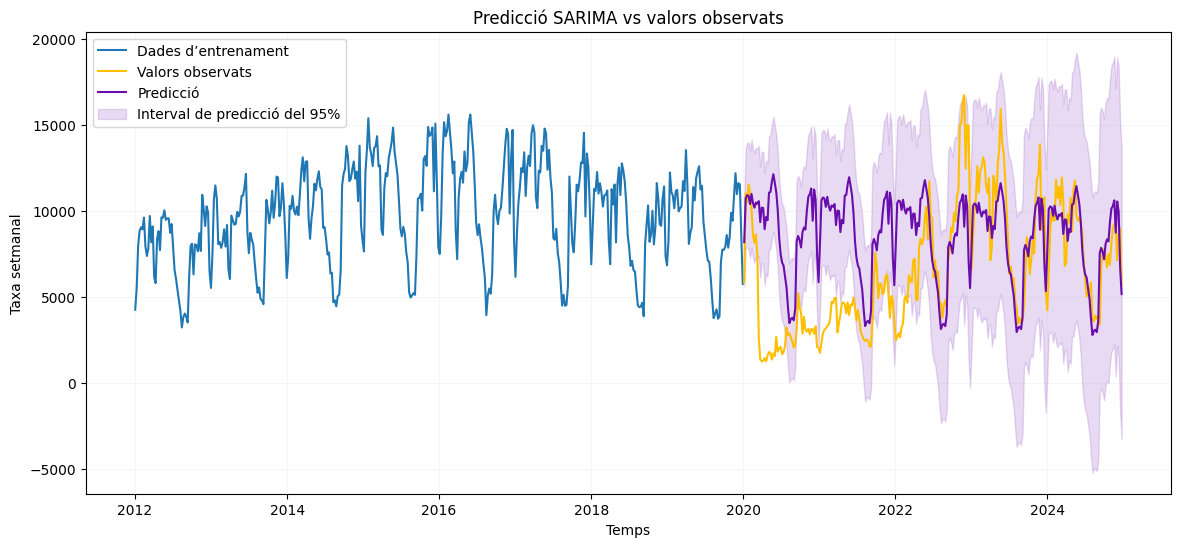

In [24]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Dades d’entrenament', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.legend()
plt.title("Predicció SARIMA vs valors observats")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)
plt.show()

In [25]:
mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)

covTotal = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

print("TOTAL")
print("MAE:", mae_total)
print("RMSE:", rmse_total)
print("Cobertura:", covTotal)

TOTAL
MAE: 3167.841257580462
RMSE: 4099.871500851928
Cobertura: 0.7153846153846154


## Avaluació de la predicció

Per avaluar quantitativament el rendiment predictiu, es calculen mètriques d’error com:

- Error absolut mitjà (MAE)
- Arrel de l’error quadràtic mitjà (RMSE)

Aquestes mètriques mesuren la diferència entre els valors observats i els valors predits, i permeten valorar la precisió del model.

La cobertura empírica dels intervals de predicció del 95% és d’aproximadament 0'72, per sota del nivell nominal, fet que suggereix que la incertesa de la predicció està infraestimada.

Per analitzar-ho amb més detall, el període de test es divideix en dos subperíodes:

- Període COVID
- Període post-COVID

Això permet estudiar si el model es comporta de manera diferent davant de canvis estructurals en les dades.

In [26]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

 
mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)

cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

print("\nCOVID (2020-2021)")
print("MAE:", mae_covid)
print("RMSE:", rmse_covid)
print("Cobertura:", cov_covid)


mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)

cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

print("\nPOST-COVID (2022-2024)")
print("MAE:", mae_post)
print("RMSE:", rmse_post)
print("Cobertura:", cov_post)


COVID (2020-2021)
MAE: 4885.054482506688
RMSE: 5578.518765508442
Cobertura: 0.38461538461538464

POST-COVID (2022-2024)
MAE: 2023.0324409629777
RMSE: 2695.9839504486154
Cobertura: 0.9358974358974359


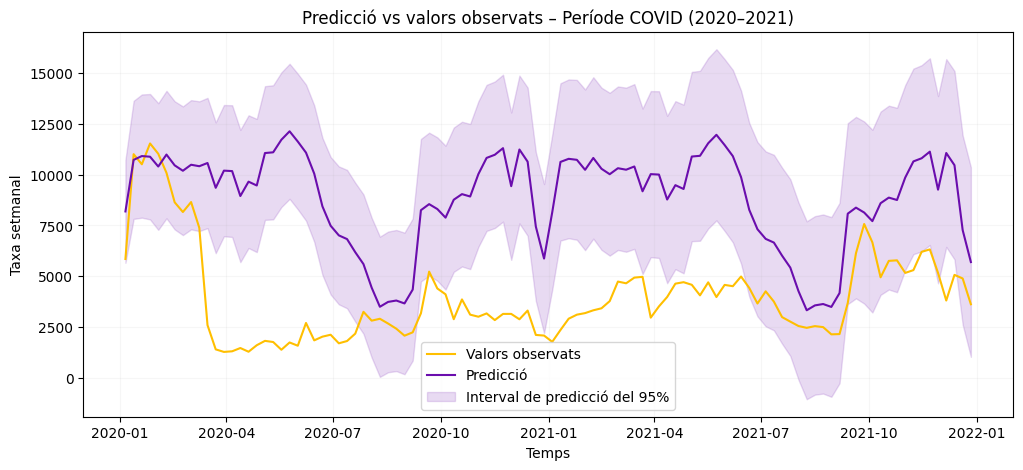

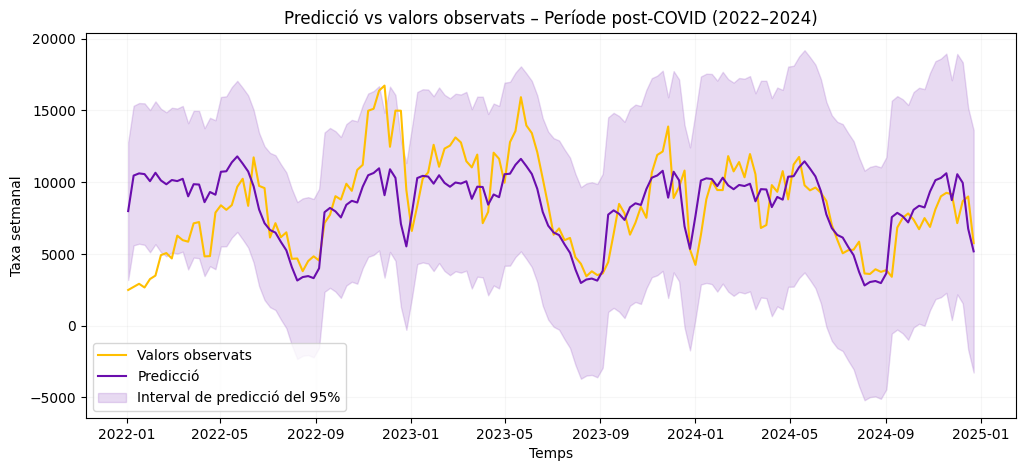

In [27]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Predicció vs valors observats – Període COVID (2020–2021)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Predicció vs valors observats – Període post-COVID (2022–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

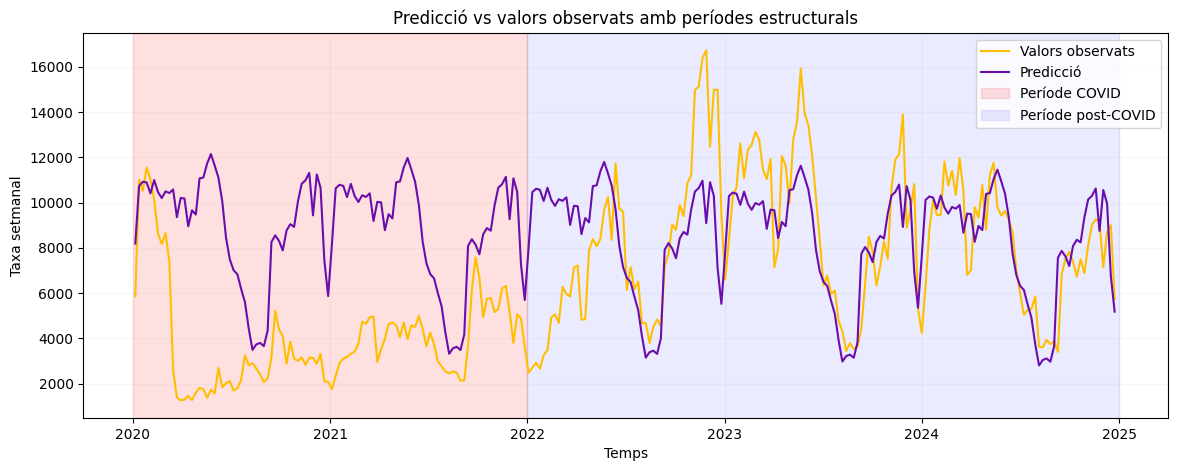

In [28]:
plt.figure(figsize=(14,5))

plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.axvspan(pd.to_datetime("2020-01-01"),
            pd.to_datetime("2021-12-31"),
            color='red', alpha=0.12, label='Període COVID')

plt.axvspan(pd.to_datetime("2022-01-01"),
            pd.to_datetime("2024-12-31"),
            color='blue', alpha=0.08, label='Període post-COVID')

plt.legend()
plt.title("Predicció vs valors observats amb períodes estructurals")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)

plt.show()

## Anàlisi visual

Durant el període COVID (2020–2021), els valors observats mostren una caiguda pronunciada i una disrupció estructural que el model no és capaç de capturar. Com a resultat, les prediccions sobreestimen sistemàticament els valors reals, cosa que genera errors de predicció més elevats i una cobertura baixa.

Aquest comportament reflecteix un trencament estructural causat per factors externs, com els confinaments, el distanciament social i la reducció de la transmissió, que no eren presents en les dades d’entrenament.

En canvi, durant el període post-COVID (2022–2024), la sèrie recupera un patró estacional més regular. Aleshores, el model és capaç d’alinear-se millor amb els valors observats, capturant tant el nivell com les fluctuacions estacionals amb bona precisió.

Això posa de manifest una propietat clau dels models SARIMA: funcionen bé en condicions estables, però tenen dificultats davant canvis estructurals sobtats. Per tant, poden ser útils no només per a la predicció, sinó també per detectar períodes anòmals.